In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def norma_complexa(zc:complex):
  return np.sqrt(np.real(zc*np.conjugate(zc)))

##Determinação de regição de estabilidade para Euler Exponencial

In [ ]:
def phi1(hc):
  if hc == 0:
    f = 1
    return f
  else:
    f = (np.exp(hc) - 1)/(hc)
    return f

def phi2(hc):
  if hc == 0:
    f = 0.5
    return f
  else:
    f = (np.exp(hc) - hc - 1)/(hc)**2
    return f

def phi3(hc):
  if hc == 0:
    f = 1/6
    return f
  else:
    f = (phi2(hc) - 1/2)/(hc)
    return f

def fator_exp_1(z,ch):
  f = np.exp(ch) + z*phi1(ch)
  return f

def fator_exp_2_1(z,ch): #c_2 = 1
  f = np.exp(ch) + (phi1(ch) - phi2(ch))*z + phi2(ch)*z*(np.exp(ch) + phi1(ch)*z)
  return f

def fator_exp_2_2(z,ch): #c_2 = 1/2
  f = np.exp(ch) + (phi1(ch) - 2*phi2(ch))*z + 2*phi2(ch)*z*(np.exp(ch*0.5) + 0.5*phi1(0.5*ch)*z)
  return f

def fator_exp_3(z,ch): #cox
  a = np.exp(ch*0.5) + 0.5*z*phi1(ch*0.5)
  b = np.exp(ch) -phi1(ch)*z + 2*z*a*phi1(ch)
  f = np.exp(ch) + (4*phi3(ch) - 3*phi2(ch) + phi1(ch))*z + z*a*(-8*phi3(ch) + 4*phi2(ch)) + z*b*(4*phi3(ch) - phi2(ch))
  return f

def fator_etd2(z,ch):
  if ch == 0:
    coef = [1,-(1 + 3*z/2),z/2]
  else:
    coef = [ch**2, - ((ch**2)*np.exp(ch)+z*((1+ch)*np.exp(ch)-1-2*ch)), z*(np.exp(ch)-1-ch)]
  solv = np.roots(coef)
  f = np.max(norma_complexa(solv))
  return f

In [ ]:
def Metodo2(func,tol = 10**(-2)):
  N = 1000
  x = np.linspace(-10,10,N)
  y = np.linspace(-10,10,N)

  xcurl = np.array([])
  ycurl = np.array([])


  for i in range(N):
    for j in range(N):
      norma = func(x[i], y[j])
      if norma > -1 and norma < 1 :
        xcurl = np.append(xcurl,x[i])
        ycurl = np.append(ycurl,y[j])

  return xcurl,ycurl

In [ ]:
met = fator_exp_1

x1,y1 = Metodo2(met)


<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1001/750119472.py:17: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/750119472.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/750119472.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

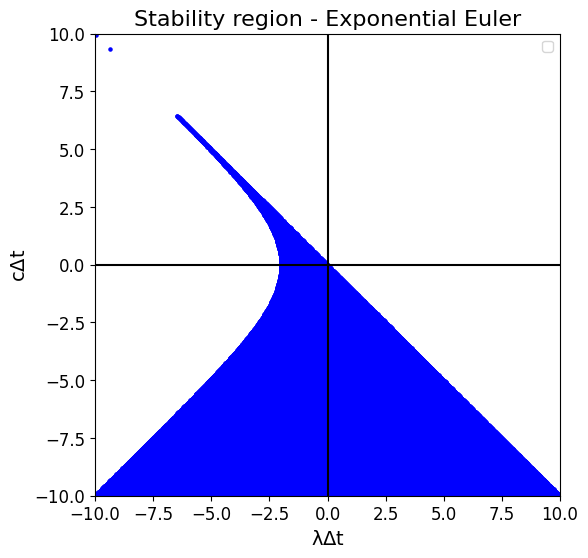

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x1,y1,color = 'b',s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-10,10)
plt.ylim(-10,10)
plt.legend()
plt.title('Stability region - Exponential Euler', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)

#Determinação de região de estabilidade para Euler exponencial aumentada

In [ ]:
def Metodo3(func,tol = 10**(-2)):
  N = 1000
  x = np.linspace(-100,100,N)
  y = np.linspace(-100,10,N)

  xcurl = np.array([])
  ycurl = np.array([])


  for i in range(N):
    for j in range(N):
      norma = func(x[i], y[j])
      if norma > -1 and norma < 1 :
        xcurl = np.append(xcurl,x[i])
        ycurl = np.append(ycurl,y[j])

  return xcurl,ycurl

In [ ]:
met_2 = fator_exp_1

x2,y2 = Metodo3(met_2)

<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1001/220849786.py:17: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/220849786.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/220849786.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

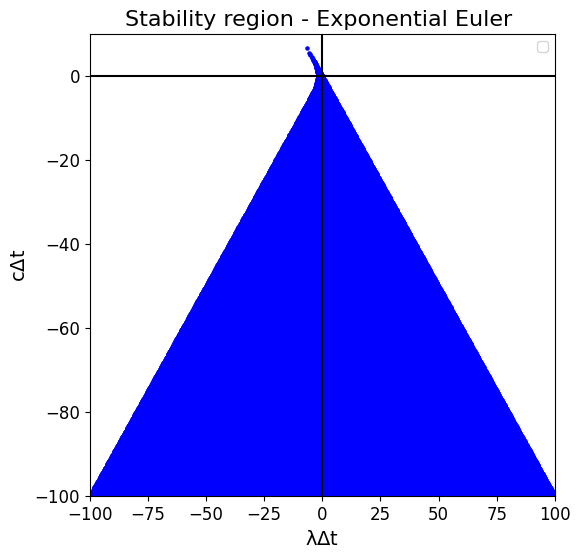

In [ ]:
axxp = (0,0)
axxn = (100,-100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x2,y2,color = 'b',s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-100,100)
plt.ylim(-100,10)
plt.legend()
plt.title('Stability region - Exponential Euler ', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)

##Determinação de regição de estabilidade para ETD2RK1 e 2

In [ ]:
met = fator_exp_2_1

x3,y3 = Metodo2(met)



<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1001/3024325880.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/3024325880.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/3024325880.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

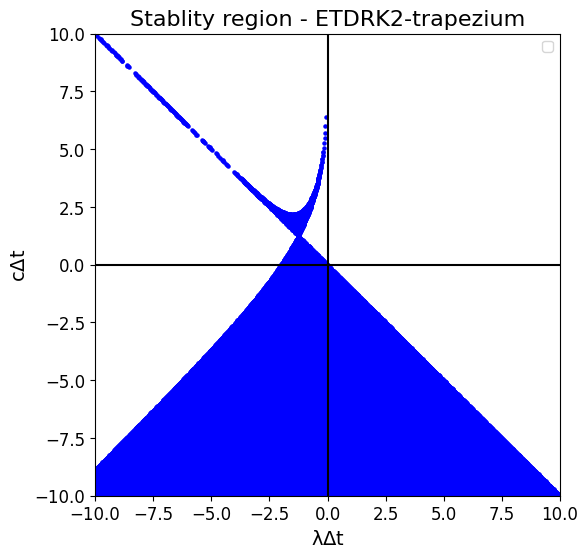

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x3,y3,color = 'b',s = 5)

ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-10,10)
plt.ylim(-10,10)
plt.legend()
plt.title('Stablity region - ETDRK2-trapezium', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)

In [ ]:
met = fator_exp_2_2

x5,y5 = Metodo2(met)




<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1001/3964658400.py:17: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/3964658400.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/3964658400.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

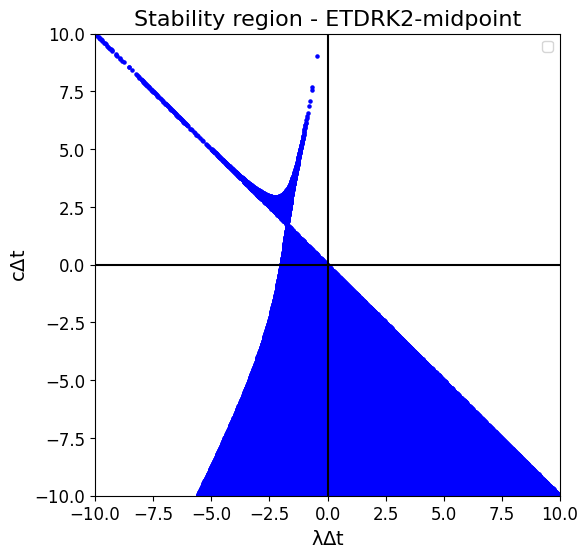

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x5,y5,color = 'b',s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-10,10)
plt.ylim(-10,10)
plt.legend()
plt.title('Stability region - ETDRK2-midpoint', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)

#Determinação de região de estabilidade para ETD2

In [ ]:
met = fator_etd2

x11,y11 = Metodo2(met)


<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1820/3123799058.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1820/3123799058.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1820/3123799058.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

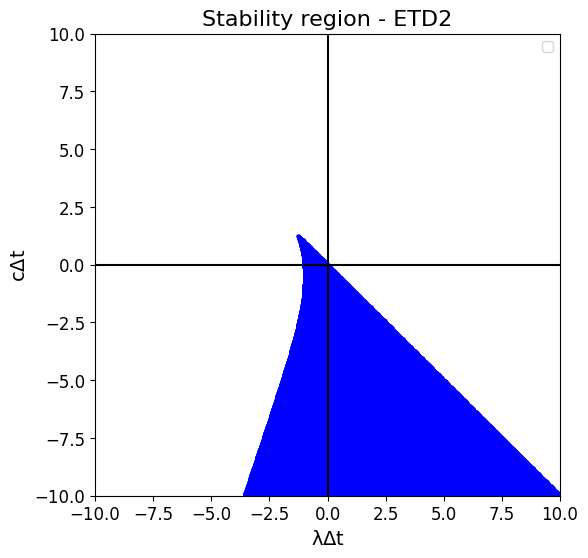

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x11,y11,color = 'b',s = 5)

ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-10,10)
plt.ylim(-10,10)
plt.legend()
plt.title('Stability region - ETD2', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)

In [ ]:
met = fator_etd2

x6,y6 = Metodo3(met)


<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1001/4078554152.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/4078554152.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/4078554152.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

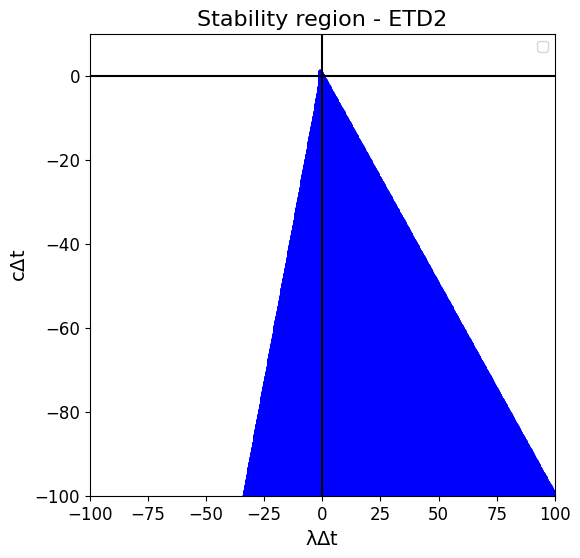

In [ ]:
axxp = (0,0)
axxn = (100,-100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x6,y6,color = 'b',s = 5)

ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-100,100)
plt.ylim(-100,10)
plt.legend()
plt.title('Stability region - ETD2', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)

In [ ]:
met = fator_exp_2_1

x10,y10 = Metodo3(met)

<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1820/1359984907.py:17: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1820/1359984907.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1820/1359984907.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

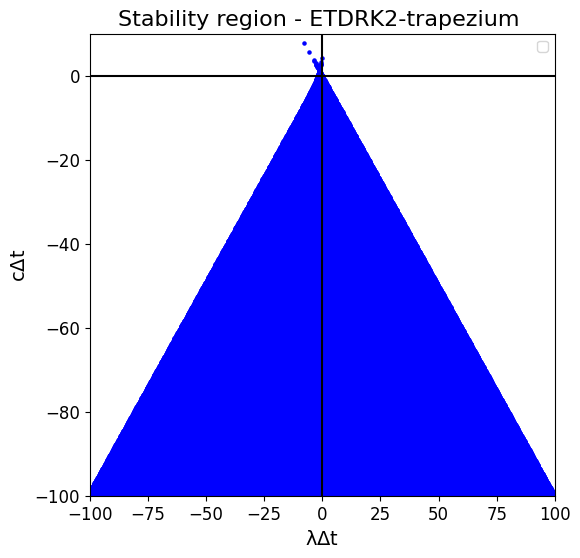

In [ ]:
axxp = (0,0)
axxn = (100,-100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x10,y10,color = 'b',s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-100,100)
plt.ylim(-100,10)
plt.legend()
plt.title('Stability region - ETDRK2-trapezium ', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)

In [ ]:
met = fator_exp_2_2

x7,y7 = Metodo3(met)

<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1001/1425578709.py:17: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/1425578709.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/1425578709.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

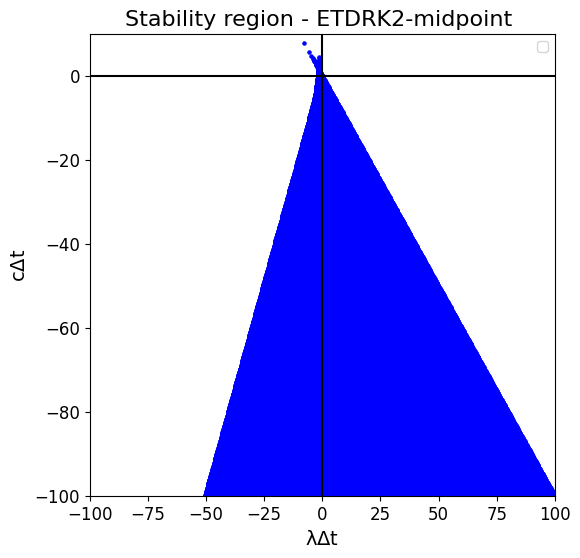

In [ ]:
axxp = (0,0)
axxn = (100,-100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x7,y7,color = 'b',s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-100,100)
plt.ylim(-100,10)
plt.legend()
plt.title('Stability region - ETDRK2-midpoint ', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)

#ETDRK3

In [ ]:
met = fator_exp_3

x8,y8 = Metodo2(met)

<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1001/2364340136.py:17: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/2364340136.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/2364340136.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

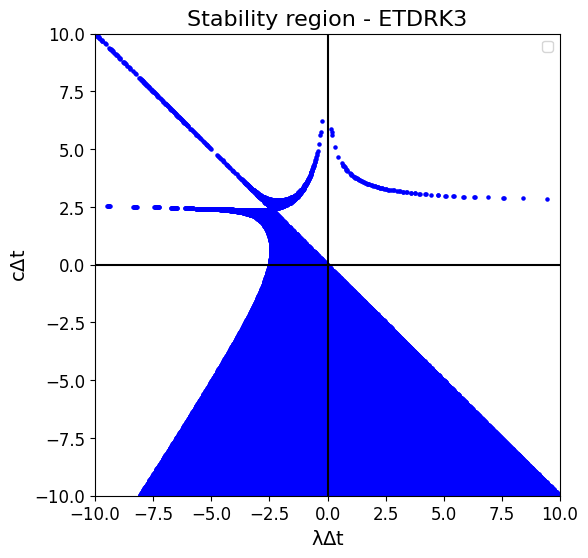

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x8,y8,color = 'b',s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-10,10)
plt.ylim(-10,10)
plt.legend()
plt.title('Stability region - ETDRK3', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)

In [ ]:
met = fator_exp_3

x9,y9 = Metodo3(met)

<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1001/3184279933.py:17: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('c$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/3184279933.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('λ$\Delta$t', fontsize = 14)
/tmp/ipykernel_1001/3184279933.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'λ$\\Delta$t')

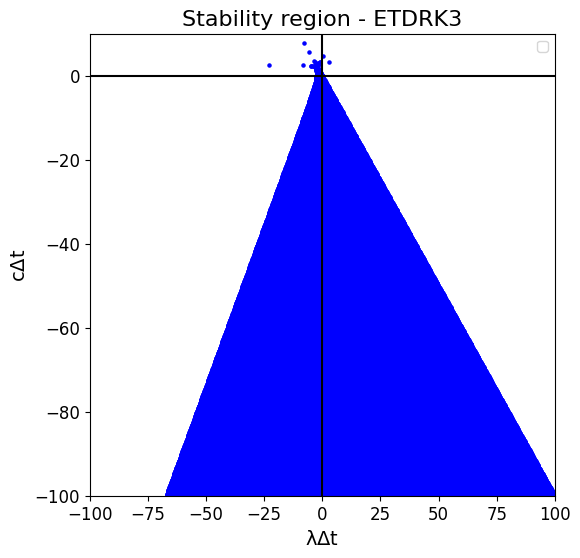

In [ ]:
axxp = (0,0)
axxn = (100,-100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x9,y9,color = 'b',s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')


plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-100,100)
plt.ylim(-100,10)
plt.legend()
plt.title('Stability region - ETDRK3', fontsize = 16)
plt.ylabel('c$\Delta$t', fontsize = 14)
plt.xlabel('λ$\Delta$t', fontsize = 14)